In [1]:
## Step 1: Import packages and libraries
!pip install yfinance pandas numpy matplotlib

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
## Step 2: Get the Stock Data
#we will use Apple (AAPL)
data = yf.download('NVDA', start='2024-01-01', end='2025-01-01')
data.head()

/tmp/ipython-input-217293526.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('NVDA', start='2024-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2024-01-02,48.141178,49.267549,47.568499,49.216579,411254000
2024-01-03,47.542515,48.157170,47.293653,47.458562,320896000
2024-01-04,47.971279,48.472999,47.481550,47.740405,306535000
2024-01-05,49.069664,49.519414,48.279104,48.435019,415039000
2024-01-08,52.223900,52.245891,49.451446,49.484429,642510000


In [8]:
## Step 3: Calculate Moving Averages
## Short-term and Long-term moving average
data['SMA20'] = data['Close'].rolling(window=20).mean()
data['SMA50'] = data['Close'].rolling(window=50).mean()



In [9]:
### Step 4: Create Buy/Sell Signals
## Initialise Signal Column

data['Signal'] = 0

## Properly asign signals using iloc
signal_values = np.where(data['SMA20'][20:] > data['SMA50'][20:], 1, 0)
data.iloc[20:, data.columns.get_loc('Signal')] = signal_values

##now safely create position column based on signal changes
data['Position'] = data['Signal'].diff()



Text(0.5, 1.0, 'SMA CROSSOVER STRATEGY')

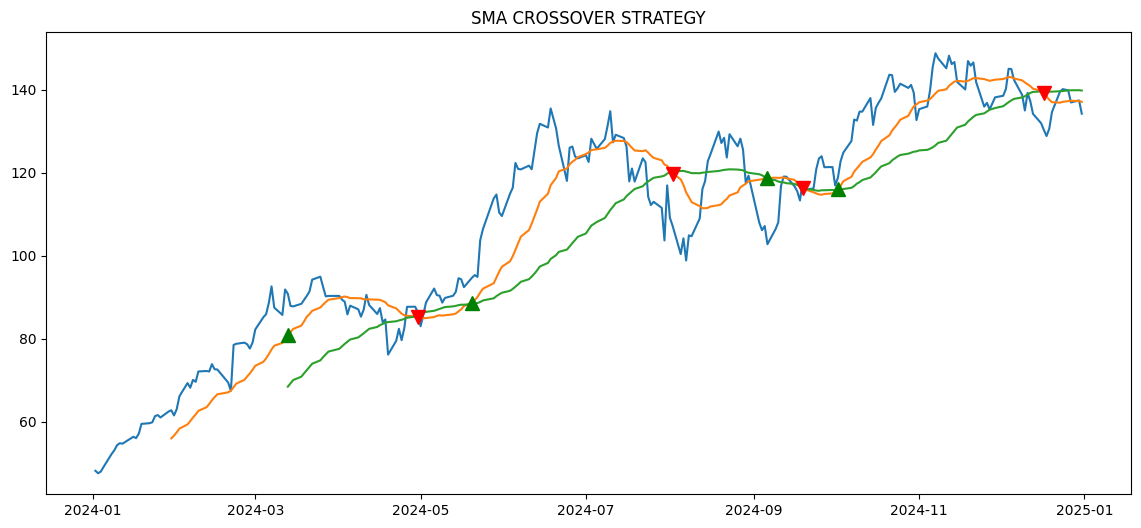

In [10]:
## Step 5: Plot the Strategy
plt.figure(figsize=(14, 6))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['SMA20'], label='SMA 20')
plt.plot(data['SMA50'], label='SMA 50')
plt.plot(data[data['Position'] == 1].index, data['SMA20'][data['Position'] ==1],'^',markersize=10, color='green', label='Buy Signal')
plt.plot(data[data['Position'] == -1].index, data['SMA20'][data['Position'] == -1], 'v', markersize=10, color='red', label='Sell Signal')
plt.title('SMA CROSSOVER STRATEGY')